In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm
import matplotlib
from matplotlib.colors import ListedColormap
import scipy.io
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import matplotlib.colors as mcolors

In [2]:
from matplotlib.colors import LinearSegmentedColormap

In [4]:
#data=np.load("datos_finales_indicios_7param.npz")
data=np.load("datos_finales_indicios_7param.npz")

In [3]:
data.keys()

KeysView(NpzFile 'datos_finales_indicios_7param.npz' with keys: params_proposed_history, params_accepted_history, rss_proposed_history, rss_accepted_history, acceptance_history...)

In [5]:
params_proposed_history=data["params_proposed_history"]
params_accepted_history=data["params_accepted_history"]
acceptance_history=data["acceptance_history"]
rss_accepted_history=data["rss_accepted_history"]
#log_posterior_history=data["log_posterior_history"]
#log_posterior_diff=data["log_posterior_diff_history"]
AR_parameter=data["AR_parameter"]
new_parameter=data["new_parameter"]
sigma_new=data["sigma_new"]
#D= data["D"]
#D_shelf=data["D_shelf"]

In [4]:
D.shape

(41, 2978, 6)

Los parámetros con los índices son  
  
0. Kmax  
1. Kmin  
2. Spec_max  
3. Spec_min  
4. Q10  
5. Ext_intercept
6. ext_slope  

In [6]:
mu=np.array([161,19,0.035,0.002,1.75])
variables = ['Kmax', 'Kmin', 'λmax', 'λmin', 'Q10']

In [ ]:
params_accepted_history.shape

(2002, 5, 6)

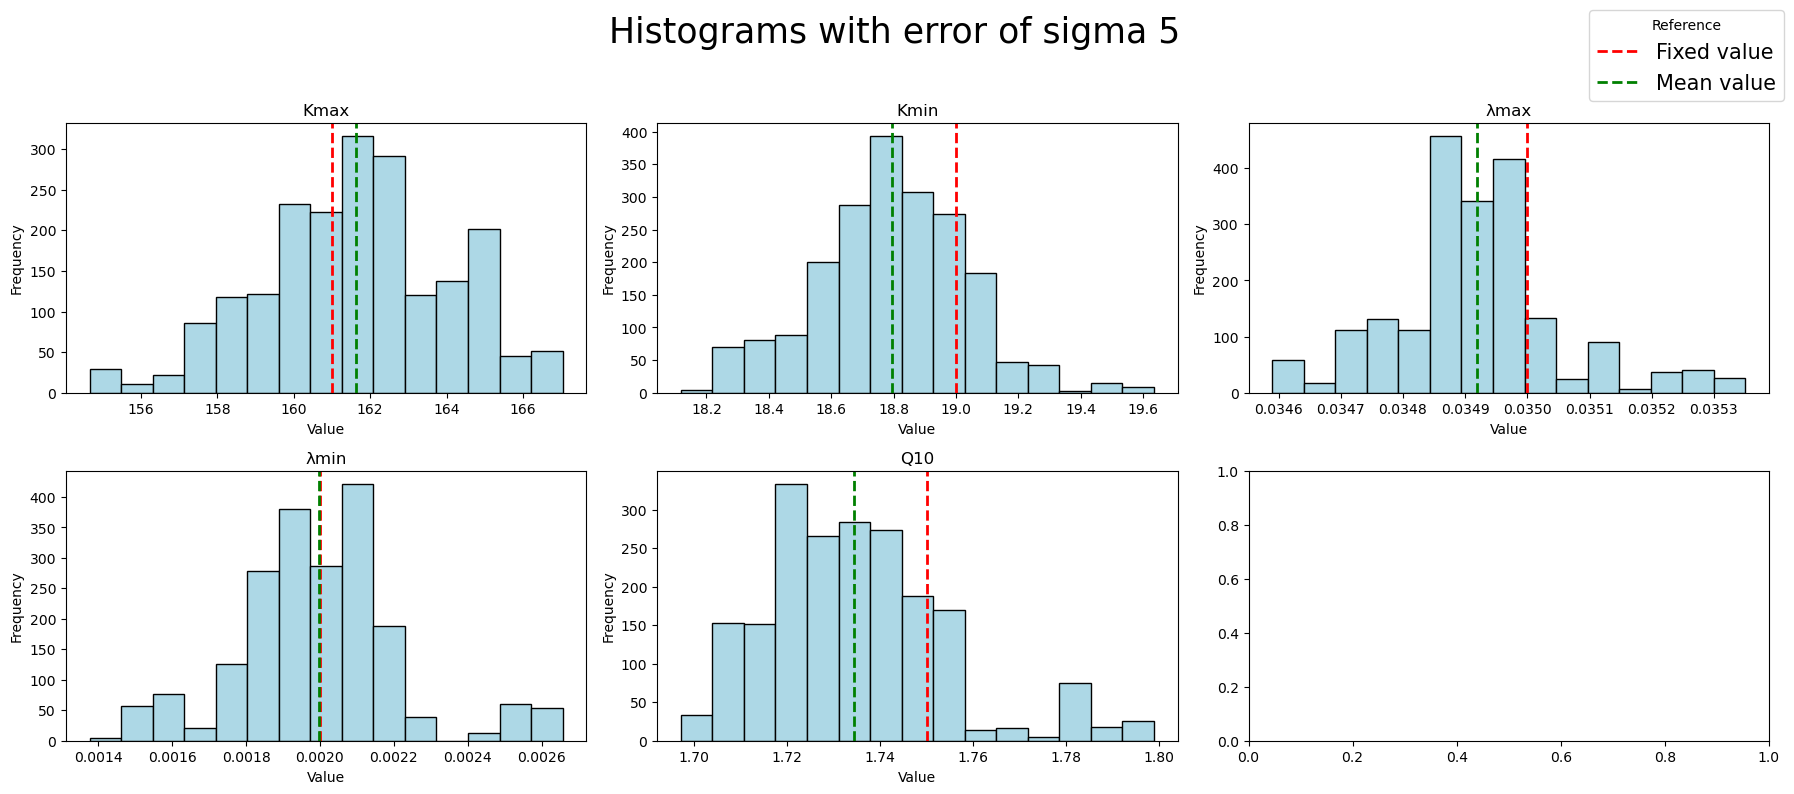

In [7]:
# Crear figura y ejes con 2 filas y 3 columnas
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)

# Aplanamos el arreglo de ejes para indexarlo fácilmente
axs = axs.flatten()

for j in range(5):
    ax = axs[j]
    line = ax.axvline(x=mu[j], color='red', linestyle='--', linewidth=2, label='Fixed value')
    
    combined_data = np.concatenate([
        params_accepted_history[1000:, j, 4].ravel(),
        params_accepted_history[1000:, j, 5].ravel()
    ])

    line2 = ax.axvline(x=np.mean(combined_data), color='green', linestyle='--', linewidth=2, label='Mean value')
    ax.hist(combined_data, bins=15, edgecolor='black', color="lightblue")
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.set_title(variables[j])

# Obtener leyenda desde cualquier eje válido
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title="Reference", fontsize=15)  # Esto funciona si axs[0] tiene el label registrado

fig.suptitle('Histograms with error of sigma 5', fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [54]:
A

array([36.55545846, 25.03408573, 27.80194405, 42.41258491, 25.43028513,
       28.31263566,         nan,         nan,         nan,         nan,
       42.18935204, 29.509851  ,         nan,         nan,         nan,
       29.53546309, 29.80801239,         nan,         nan, 28.31611775,
       29.82596737, 36.0039221 ,         nan, 30.31872293, 31.70915967])

NameError: name 'A' is not defined

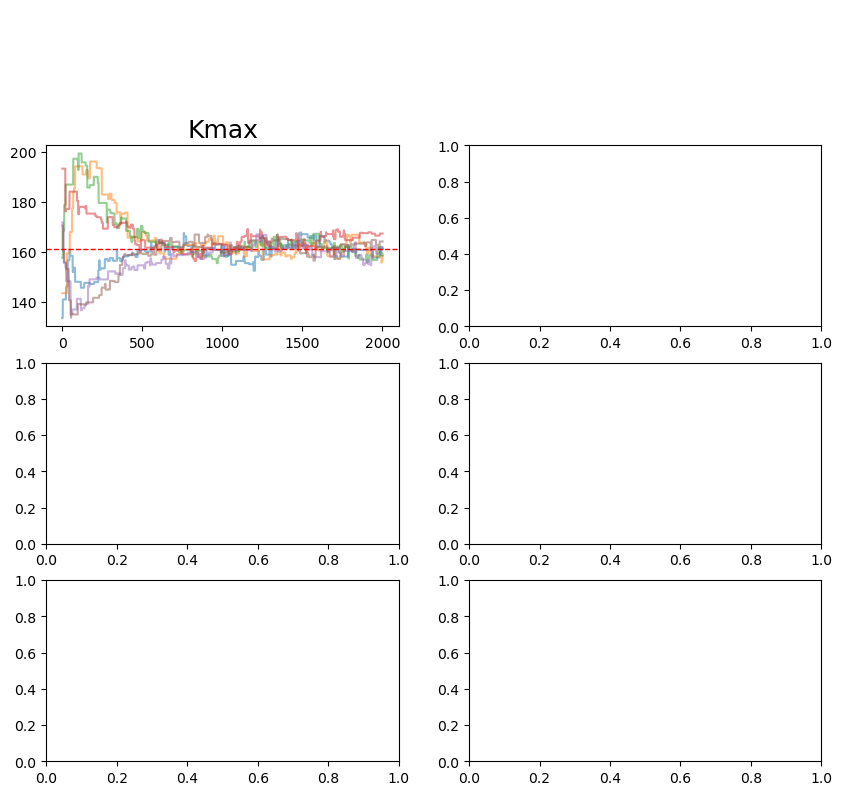

In [7]:
# Crear figura y ejes con 3 filas y 2 columnas
fig, axs = plt.subplots(3, 2, figsize=(10, 8), sharex=False, sharey=False)

# Aplanamos el arreglo de ejes para indexarlo fácilmente
axs = axs.flatten()

ax_blank = fig.add_axes([0.15, 0.9, 0.5, 0.15])  # [left, bottom, width, height]
ax_blank.axis('off')

# Graficamos solo en los primeros 5 subplots
for j in range(5):
    ax = axs[j]
    for i in range(6):

        ax.plot(np.arange(2003), params_accepted_history[:, j, i], alpha=0.5, label=f'chain {i}')
    ax.set_title(variables[j], fontsize=18)
    ax.axhline(y=mu[j], color='red', linestyle='--', linewidth=1, label='Reference value')
    ax.axhline(y=A[j], color='blue', linestyle='--', linewidth=1, label='Mean value')
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Parameter value', fontsize=12)
    #ax.axvspan(0, 200, color='black', alpha=0.2, label='burn-in')
    ax.set_xlim(0,2020)


handles, labels = axs[0].get_legend_handles_labels()

fig.legend(handles, labels, loc='lower right', fontsize=15, bbox_to_anchor=(0.95, 0.1))  # Ajusta la posición según sea necesario
#plt.legend(ncol=2)



# Ocultar el subplot vacío (el sexto)
fig.delaxes(axs[5])

# Título general
#fig.suptitle('Params accepted with error of sigma 2', fontsize=18)
plt.tight_layout(rect=[0, 0, 1.1, 1.4])  # Dejar espacio para el título
plt.savefig("Chains.pdf", bbox_inches='tight')
plt.show()

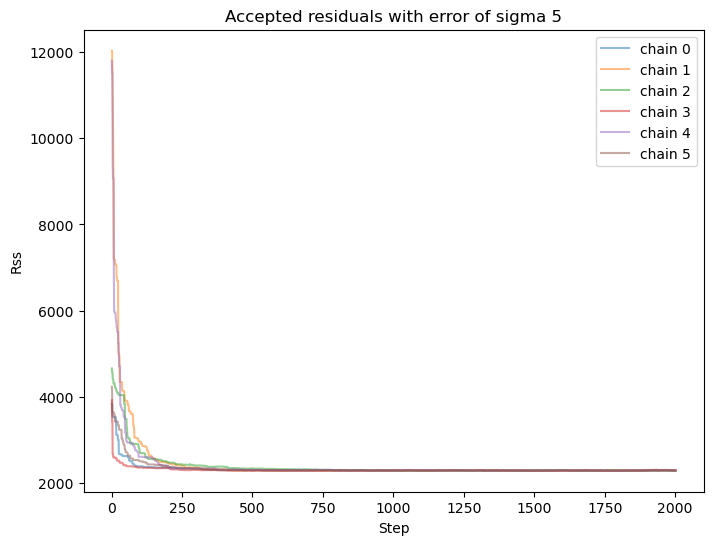

In [13]:
plt.figure(figsize=(8, 6))
for i in range(6):
    plt.plot(np.arange(1,2002), rss_accepted_history[1:,i], alpha=0.5, label=f'chain {i}')
plt.xlabel('Step')
plt.ylabel('Rss')
plt.legend()
plt.title(f'Accepted residuals with error of sigma 5')
plt.show()

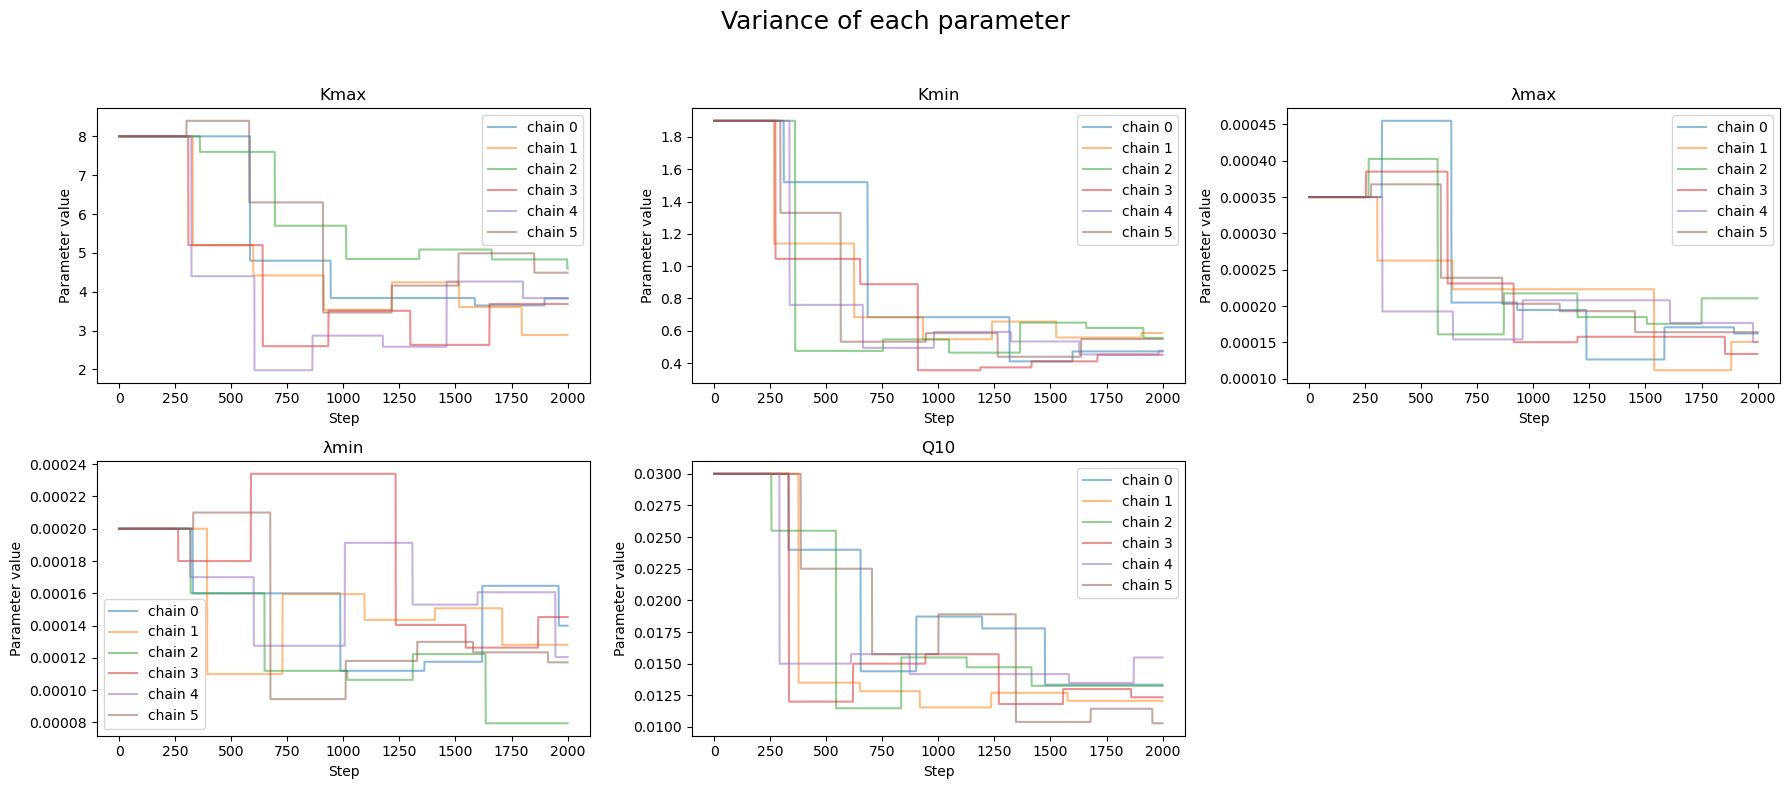

In [12]:
# Crear figura y ejes con 2 filas y 3 columnas
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)

# Aplanamos el arreglo de ejes para indexarlo fácilmente
axs = axs.flatten()

# Graficamos solo en los primeros 5 subplots
for j in range(5):
    ax = axs[j]
    for i in range(6):
        ax.plot(np.arange(1, 2001), sigma_new[1:, j, i], alpha=0.5, label=f'chain {i}')
    ax.set_title(variables[j])
    ax.set_xlabel('Step')
    ax.set_ylabel('Parameter value')
    ax.legend()

# Ocultar el subplot vacío (el sexto)
fig.delaxes(axs[5])

# Título general
fig.suptitle('Variance of each parameter', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Dejar espacio para el título
plt.show()


In [76]:
for i in range(6):
    acceptance_1=acceptance_history[1:,i]
    print(f"El acceptance rate de la cadena {i} es {np.sum(acceptance_1)/len(acceptance_1)}")


El acceptance rate de la cadena 0 es 0.4385
El acceptance rate de la cadena 1 es 0.0425
El acceptance rate de la cadena 2 es 0.0
El acceptance rate de la cadena 3 es 0.011
El acceptance rate de la cadena 4 es 0.5165
El acceptance rate de la cadena 5 es 0.0


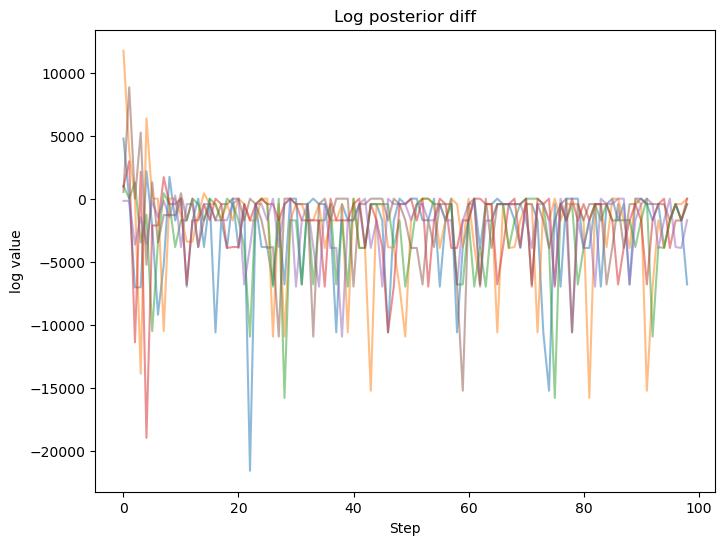

In [13]:
plt.figure(figsize=(8, 6))
for i in range(6):
    plt.plot(np.arange(99), log_posterior_diff[1:,i], alpha=0.5, label=f'chain {i}')
plt.xlabel('Step')
plt.ylabel('log value')
#plt.legend()
plt.title(f'Log posterior diff')
plt.show()

In [21]:
import numpy as np
datos_proof=np.load("datos_proof_2.npz")

In [22]:
proof=datos_proof["proof"]

In [95]:
proof

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [40]:
len(proof[~np.isnan(proof)])

2978

In [82]:
proof.shape

(360, 720)

In [32]:
datos_alphadiv=np.load("datos_prueba_alphadiv_opt.npz")

In [33]:
datos_alphadiv.keys()

KeysView(NpzFile 'datos_prueba_alphadiv_opt.npz' with keys: D_car, D_med, D_pac, arr_0, arr_1)

In [34]:
model=datos_alphadiv["D"]

KeyError: 'D is not a file in the archive'

In [29]:
len(model[~np.isnan(model)])

2978

In [8]:
import mat73

data=mat73.loadmat('landShelfOceanMask_ContMargMaskKocsisScotese.mat')
landShelfOcean_Lat=data['landShelfOcean_Lat']
landShelfOcean_Lon=data['landShelfOcean_Lon']
landShelfOceanMask=data['landShelfOceanMask']
landShelfOceanMask = np.flip(landShelfOceanMask, axis=2)

In [9]:
LSOmask=np.transpose(landShelfOceanMask[:,:,landShelfOceanMask.shape[2]-1])

In [10]:
LSOmask.shape

(360, 720)

In [10]:
lats=landShelfOcean_Lat
lons=landShelfOcean_Lon

In [10]:
mascara_validos = ~np.isnan(proof)

In [42]:
datos_mapa = np.full((360, 720), np.nan)

In [34]:
D.shape

(81, 2978, 6)

In [35]:
len(proof[~np.isnan(proof)])

2978

In [123]:
datos_mapa.shape

(360, 720)

In [51]:
data_slice = D[5:,:,:]

In [50]:
D.shape

(41, 2978, 6)

In [52]:
mean_D= np.nanmean(data_slice, axis=(0,2))
std_D= np.nanstd(data_slice, axis=(0,2))


In [53]:
datos_mapa[mascara_validos]=std_D

In [47]:
mean_D.shape

(2978,)

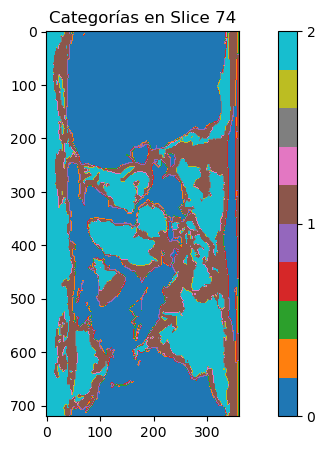

In [15]:
import matplotlib.pyplot as plt

mask = landShelfOceanMask[:, :, 65]

plt.figure(figsize=(10, 5))
im = plt.imshow(mask, cmap="tab10")  # tab10 es bueno para categorías
plt.colorbar(im, ticks=[0, 1, 2])    # Ajusta ticks según valores presentes
plt.title("Categorías en Slice 74")
plt.show()


In [41]:
cmap = LinearSegmentedColormap.from_list("white_blue", ["white", "blue",  "red"])

C:\Users\glode\AppData\Local\Temp\ipykernel_14924\4208371381.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])  # Dejar espacio para el título


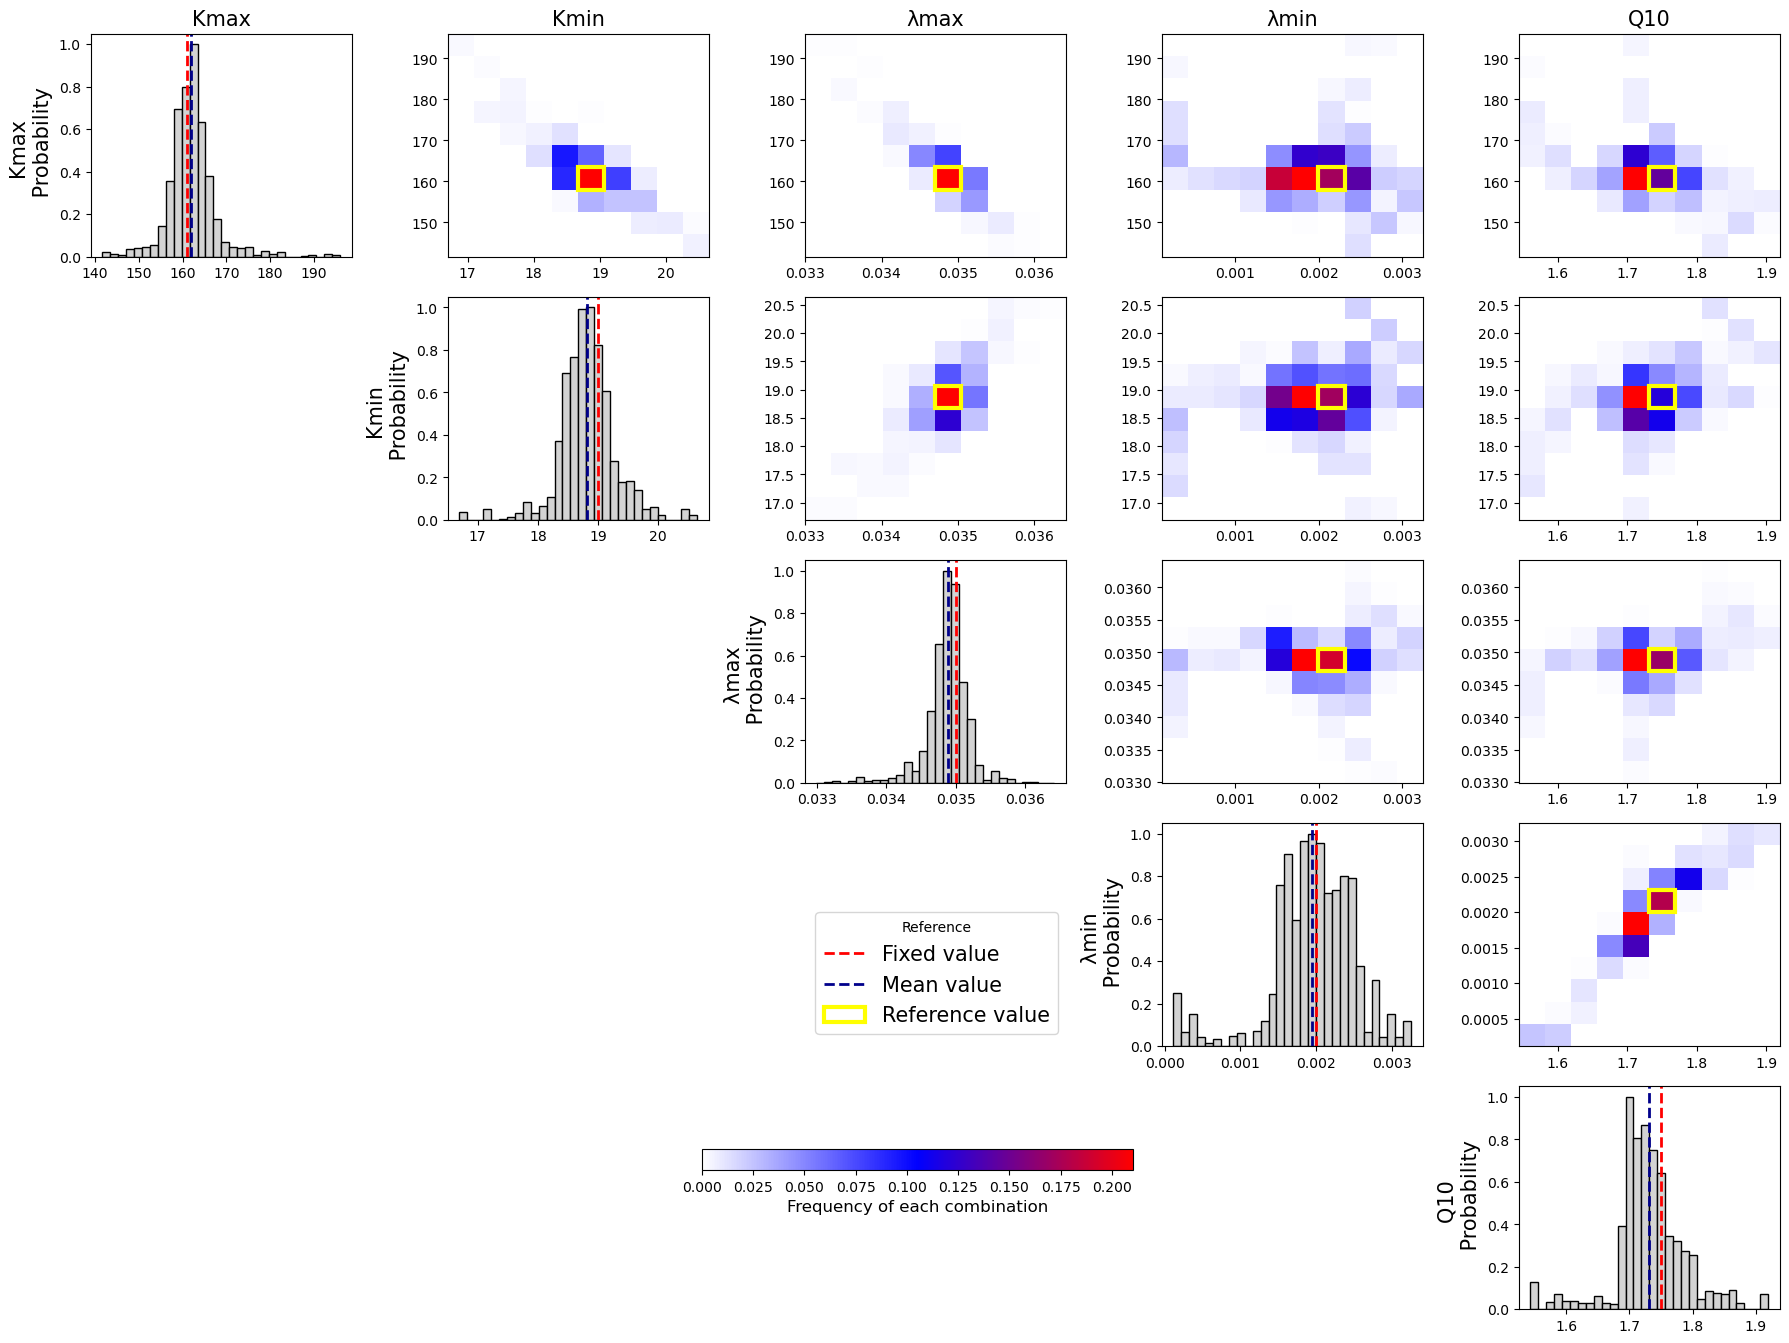

In [47]:
# Datos de muestra

global_min = np.inf
global_max = -np.inf


fig, axs = plt.subplots(5, 5, figsize=(18, 14), sharex=False, sharey=False)

for i in range(5):

    for j in range(5):

        if i==j:

            ax = axs[i,j]
            line = ax.axvline(x=mu[j], color='red', linestyle='--', linewidth=2, label='Fixed value')
            line2 = ax.axvline(x=np.mean(params_accepted_history[200:,j]), color='darkblue', linestyle='--', linewidth=2, label='Mean value')
            data = params_accepted_history[200:, j].ravel().astype(float)
            # Calcular el histograma
            counts, bins = np.histogram(data, bins=30)

            # Normalizar al máximo = 1
            counts = counts / counts.max()

            # Graficar manualmente
            ax.bar((bins[:-1] + bins[1:]) / 2,   # posiciones de las barras (centros)
                   counts,                       # alturas normalizadas
                   width=np.diff(bins),          # anchura de cada bin
                   align="center",
                   edgecolor='black',
                   color='lightgray')

            ax.set_ylabel(f'{variables[i]} \n Probability', fontsize=15)

            
            #ax.set_title(variables[j])
            if i==0:
                ax.set_title(variables[j], fontsize=15)

        elif j>i:
            
            ax = axs[i, j]
            x = params_accepted_history[200:, j, :].ravel()
            y = params_accepted_history[200:, i, :].ravel()

            weights = np.ones_like(x) / len(x)
            hist = ax.hist2d(x, y, weights=weights, cmap=cmap)



            fixed_value_x=mu[j]
            fixed_value_y=mu[i]

            H, x_edges, y_edges = np.histogram2d(x, y, bins=20)



            global_min = min(global_min, H.min())
            global_max = max(global_max, H.max())

            H=hist[0]
            im=hist[3]

            H_rel = H / H.sum()  
            #im.set_array(H_rel.ravel())  

            x_edges= hist[1]
            y_edges= hist[2]

            x_bin = np.digitize(fixed_value_x, x_edges) - 1
            y_bin = np.digitize(fixed_value_y, y_edges) - 1

            x_start = x_edges[x_bin]
            y_start = y_edges[y_bin]
            bin_width = x_edges[1] - x_edges[0]
            bin_height = y_edges[1] - y_edges[0]

            # Dibujar un rectángulo rojo
            rect = Rectangle((x_start, y_start), bin_width, bin_height,
                             edgecolor='yellow', facecolor='none', linewidth=3, label='Reference value')
            ax.add_patch(rect)

           # ax.set_xlabel(variables[j])
           # ax.set_ylabel(variables[i])
            if i==0:
                ax.set_title(variables[j], fontsize=15)
         
           # ax.set_title(f'{variables[j]} vs {variables[i]}')

        else:
            fig.delaxes(axs[i,j])
            

# Título general


cbar = fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.02, pad=0.02)
cbar.set_label("Frequency of each combination", fontsize=12)

handles1, labels1 = axs[0,0].get_legend_handles_labels()
handles2, labels2 = axs[0,1].get_legend_handles_labels()
handles = handles1 + handles2
labels = labels1 + labels2

fig.legend(handles, labels, loc='lower left', title="Reference", fontsize=15, bbox_to_anchor=(0.45, 0.2))

#fig.suptitle('Histograms 2D with 2 sigma in the error', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Dejar espacio para el título
plt.savefig("histogram2D.pdf")
plt.show()


In [8]:
A=[]
S=[]
Q_05=[]
Q_95=[]
for j in range(5):
    A.append(np.mean(params_accepted_history[200:,j]))
    S.append(np.std(params_accepted_history[200:,j]))
    Q_05.append(np.percentile(params_accepted_history[200:,j], 5))
    Q_95.append(np.percentile(params_accepted_history[200:,j], 95))


In [7]:
S, A

([5.67712070052902,
  0.47251758602495103,
  0.0003058910685488491,
  0.0005719503548025827,
  0.05772972549892713],
 [162.00488088488993,
  18.818472691756767,
  0.03488556277361442,
  0.001948704039919627,
  1.7312796545694171])

In [14]:
np.abs(A-mu)<=S

array([ True,  True,  True,  True,  True])

In [37]:
A[3]

0.0019985118654282084

In [39]:
D_mean.shape

(360, 720)

In [5]:
import numpy as np
#data=np.load("datos_prueba_alphadiv_opt.npz")
indices=np.load("indices_por_anos_3_filt.npz")

print(indices.keys())

KeysView(NpzFile 'indices_por_anos_3_filt.npz' with keys: indices_med, indices_car, indices_pac)


In [16]:
indices_pac=indices["indices_pac"]
indices_car=indices["indices_car"]
indices_med=indices["indices_med"]

In [30]:
proof.shape

NameError: name 'proof' is not defined

In [12]:
import scipy.io
data_point_ages=scipy.io.loadmat('Point_ages_xyzKocsisScotese_400.mat')

In [13]:
shelf_lonlatAge=data_point_ages['shelf_lonlatAge']
Point_timeslices=data_point_ages['Point_timeslices']

In [37]:
D_shelf.shape

(41, 49688, 82, 6)

In [ ]:
indices
D_med=D_shelf[:,indices_med.astype(int),:,0]

C:\Users\glode\AppData\Local\Temp\ipykernel_35676\2121491123.py:1: RuntimeWarning: invalid value encountered in cast
  D_med=D_shelf[:,indices_med.astype(int),:,0]


IndexError: index -2147483648 is out of bounds for axis 1 with size 49688

In [94]:
D_med.shape

(25, 41, 82)

In [92]:
len(indices_med)

25

In [38]:
indices_med.shape

(82, 96)

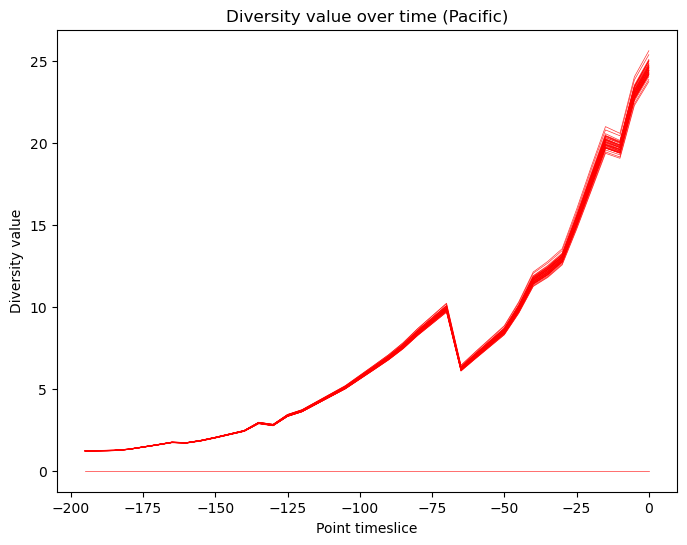

In [50]:
plt.figure(figsize=(8, 6))


mean_values = np.zeros(shelf_lonlatAge.shape[1])
year = np.full(shelf_lonlatAge.shape[1], np.nan)

for a in range(D_shelf.shape[0]):
    for t in range(50,shelf_lonlatAge.shape[1]):
        ind_pac=indices_pac[t,:]
        ind_pac=ind_pac[~np.isnan(ind_pac)]
        D_car=D_shelf[:,ind_pac.astype(int),:,0]
        A = np.zeros((len(ind_pac)))
        for i in range(len(ind_pac)):
            A[i] = D_car[i,a,t]

        mean_values[t] = np.nanmean(A)

        if not np.isnan(mean_values[t]):
            year[t] = Point_timeslices[0][t]

    # ⚠️ Solo después de llenar 'year', creamos el mask
    mask = ~np.isnan(year)
    #for line in [-440, -380, -330, -252, -202, -66]:
    #    plt.axvline(x=line,linestyle='--', color='black', alpha=0.5)
    plt.plot(-year[mask], mean_values[mask], color='r', alpha=0.8, linewidth=0.5, label='Media')

plt.xlabel('Point timeslice')
plt.ylabel('Diversity value')
plt.title('Diversity value over time (Pacific)')
#plt.legend()
plt.show()

In [22]:
ind_med.shape

(96,)

Here, we want to represent the maps of the diversity in the proof, in the model and their difference. Furthermore, we want to represent them in a specific color scale.

In [7]:
data_proof=np.load("datos_proof_2.npz")
proof=data_proof[ "proof"]

In [29]:




lats = np.linspace(-90, 90, 360)   # 360 filas -> paso de 0.5°
lons = np.linspace(-180, 180, 720) # 720 columnas -> paso de 0.5°



In [32]:
A

[162.00488088488993,
 18.818472691756767,
 0.03488556277361442,
 0.001948704039919627,
 1.7312796545694171]

In [13]:
from principal_proof import principal
D_mean=principal(A[0], A[1], A[2], A[3], A[4])

ModuleNotFoundError: No module named 'rhonet'

In [32]:
np.savez("datos_mean.npz", D_mean=D_mean)

In [6]:
data=np.load("datos_mean.npz")
D_mean=data["D_mean"]

In [15]:
D_mean.shape

(360, 720)

In [10]:
D_mean=D_mean[:,:,81]

In [5]:
colors_bYr = np.loadtxt("mycolormap_bYr.dat")
bYr = ListedColormap(colors_bYr, name="mi_cmap_bYr")
data_color_br = scipy.io.loadmat("mycolormap_br.mat")
colors_br=data_color_br["mycolormap_br"]
br = ListedColormap(colors_br, name="mi_cmap_br")

In [11]:
lon_grid, lat_grid = np.meshgrid(lons, lats)

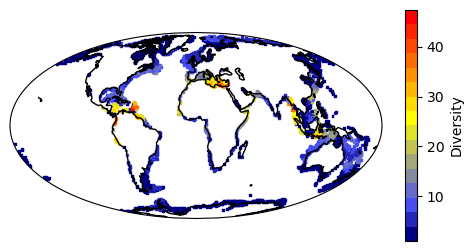

In [47]:


plt.figure(figsize=(6,3))
ax = plt.subplot(projection=ccrs.Mollweide())

# Scatter, con tamaño grande
# s controla área en píxeles cuadrados, prueba con valores grandes (ej: 100, 200, 500)
scatter = ax.scatter(lon_grid, lat_grid,
                     c=D_mean, cmap=bYr,
                     s=2, marker='s', transform=ccrs.PlateCarree())

ax.coastlines()
ax.set_global()
plt.colorbar(scatter, orientation='vertical', label='Diversity')
plt.title('')
plt.show()

In [ ]:
K=D_mean-D_interp

(360, 720)

In [173]:
K[~np.isnan(K)].max()

7.259000192716488

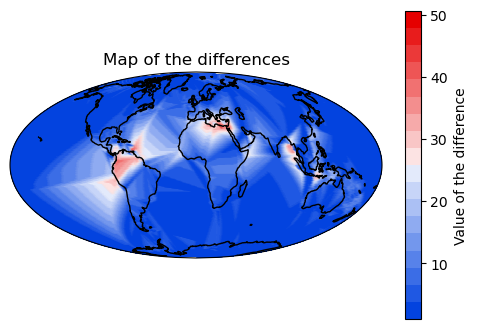

In [34]:
plt.figure(figsize=(6,4))
ax = plt.subplot(projection=ccrs.Mollweide())

# Scatter, con tamaño grande
# s controla área en píxeles cuadrados, prueba con valores grandes (ej: 100, 200, 500)
scatter = ax.scatter(lon_grid, lat_grid,
                     c=D_interp, cmap=br,
                     s=3, marker='s', transform=ccrs.PlateCarree())

ax.coastlines()
ax.set_global()
plt.colorbar(scatter, orientation='vertical', label='Value of the difference')
plt.title('Map of the differences')
plt.show()

The maps are okey, but they will be better with interpolation

In [12]:
[X,Y]=np.meshgrid(landShelfOcean_Lon,landShelfOcean_Lat)#

In [13]:
x = X.flatten()
y = Y.flatten()
z_mean = D_mean.flatten()
z_proof = proof.flatten()

In [14]:
# Eliminar NaN (para no meterlos en la interpolación)
mask_proof = ~np.isnan(z_proof) & ~np.isinf(z_proof)
mask_mean = ~np.isnan(z_mean) & ~np.isinf(z_mean)
x_valid = x[mask_proof]
y_valid = y[mask_proof]
z_mean_v = z_mean[mask_mean]
z_proof_v = z_proof[mask_proof]


In [15]:
D_mean_interp = griddata(
    (x_valid, y_valid), 
    z_mean_v, 
    (X, Y), 
    method='linear'   # puedes probar 'nearest' o 'cubic'
)
D_interp = griddata(
    (x_valid, y_valid), 
    z_proof_v, 
    (X, Y), 
    method='linear'   # puedes probar 'nearest' o 'cubic'
)

In [16]:
D_mean_interp[LSOmask != 1] = np.nan
D_interp[LSOmask != 1] = np.nan

In [17]:
K=D_interp-D_mean_interp
print(K.shape)

(360, 720)


In [18]:
D_nan=D_mean_interp[~np.isnan(D_mean_interp)]
print(len(D_nan))
D_interp_nan=D_interp[~np.isnan(D_interp)]
print(len(D_interp_nan))


41817
41817


In [56]:
proof.shape

(360, 720)

In [19]:
Q95=np.percentile(K[~np.isnan(K)],95)
Q05=np.percentile(K[~np.isnan(K)],5)
print(Q95, Q05)
K[K>Q95]=Q95
K[K<Q05]=Q05

2.350386960047363 -1.7722104929424296


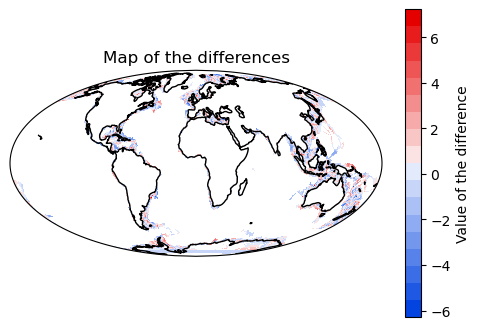

In [40]:
plt.figure(figsize=(6,4))
ax = plt.subplot(projection=ccrs.Mollweide())

# Scatter, con tamaño grande
# s controla área en píxeles cuadrados, prueba con valores grandes (ej: 100, 200, 500)


#mesh = ax.pcolormesh(X, Y, Dinterp, transform=ccrs.PlateCarree(), cmap='viridis', shading='auto')

scatter = ax.pcolormesh(lon_grid, lat_grid,
                     K, cmap=br,
                       transform=ccrs.PlateCarree())

ax.coastlines()
ax.set_global()
plt.colorbar(scatter, orientation='vertical', label='Value of the difference')
plt.title('Map of the differences')
plt.show()

We create our superfigure, combination of all of them, for the paper

In [61]:
def base2_formatter(x, pos):
    # Redondea al entero más cercano (opcional)
    # Solo mostrar valores que sean potencias de 2
    exp = int(np.round(np.log2(x)))
    val = 2 ** exp
    return f'{val}'

0.9999999999999976


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


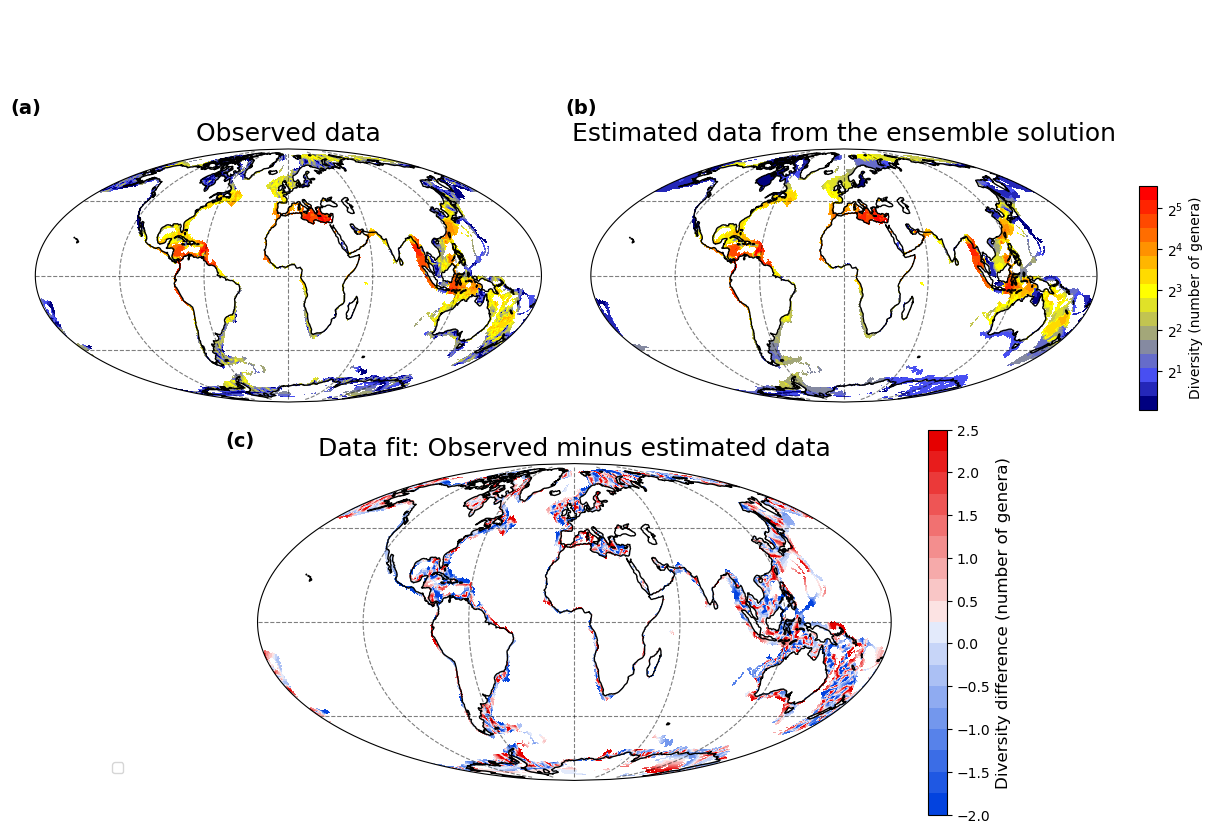

In [21]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.ticker as mticker



x = np.linspace(100, 10, 100)
y = x  # gráfico simple y = x

fig = plt.figure(figsize=(18, 16))

ax_blank = fig.add_axes([0.3, 0.9, 0.5, 0.05])  # [left, bottom, width, height]
ax_blank.axis('off')

gs = GridSpec(4, 13, figure=fig, height_ratios=[2,2.5,2,1.5], width_ratios=[1]*13, hspace=0, wspace=0.8)  # 4 filas, 4 columnas de referencia

#fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.9,
#                    wspace=1, hspace=0.4)
#fig.subplots_adjust(top=2, bottom=1)
# Fila 1: 2 figuras

vmin = min(np.nanmin(D_interp), np.nanmin(D_mean_interp))
vmax = max(np.nanmax(D_interp), np.nanmax(D_mean_interp))

print(vmin)


ax1 = fig.add_subplot(gs[0, 1:6], projection=ccrs.Mollweide())
scatter1=ax1.pcolormesh(lon_grid, lat_grid,
                     D_interp, cmap=bYr, 
                     norm=mcolors.LogNorm(vmin=vmin, vmax=vmax),
                       transform=ccrs.PlateCarree())
ax1.coastlines()
ax1.set_global()
#cbar1=plt.colorbar(scatter1, orientation='vertical')
#cbar1.set_label( label='Diversity', fontsize=12)

gl1=ax1.gridlines(draw_labels=False, linestyle='--', color='black', alpha=0.5,  ylocs=[-45, 0, 45])


ax1.set_title('Observed data', fontsize=18)



ax2 = fig.add_subplot(gs[0, 6:11], projection=ccrs.Mollweide())
scatter2=ax2.pcolormesh(lon_grid, lat_grid,
                      D_mean_interp, cmap=bYr, 
                      norm=mcolors.SymLogNorm(linthresh=0.001, base=2), 
                       transform=ccrs.PlateCarree())
ax2.coastlines()
ax2.set_global()
#cbar2=plt.colorbar(scatter2, orientation='vertical', label='Diversity')
#cbar2.set_label('Diversity', fontsize=12)

gl2=ax2.gridlines(draw_labels=False, linestyle='--', color='black', alpha=0.5,  ylocs=[-45, 0, 45])

ax2.set_title('Estimated data from the ensemble solution', fontsize=18)

cbar_ax = fig.add_axes([0.8, 0.7, 0.01, 0.14])
cbar = fig.colorbar(scatter2, ax=[ax1, ax2], cax=cbar_ax)

cbar.set_label('Diversity (number of genera)')





# Fila 2: 1 figura
ax3 = fig.add_subplot(gs[1, 3:10], projection=ccrs.Mollweide())
scatter=ax3.pcolormesh(lon_grid, lat_grid,
                     K, cmap=br,
                       transform=ccrs.PlateCarree(), vmin=-2, vmax=2.5)
ax3.coastlines()
ax3.set_global()
cbar3=plt.colorbar(scatter, orientation='vertical',  fraction=0.08)

cbar3.set_label(label='Diversity difference (number of genera)', fontsize=12)



# --- Rectángulo definido por las coordenadas exactas ---
lon_min_car, lon_max_car = -68, -55
lat_min_car, lat_max_car = 8.2, 16.2

#rect_car = Rectangle(
#    xy=(lon_min_car, lat_min_car), width=lon_max_car - lon_min_car,           # diferencia en longitudes
#    height=lat_max_car - lat_min_car, linewidth=2, edgecolor='darkblue', facecolor='none',
#    transform=ccrs.PlateCarree() , label= 'Caribbean')
#
#ax3.add_patch( rect_car)
#
#lon_min_med, lon_max_med = 26.5, 34.5
#lat_min_med, lat_max_med = 26.5, 34.5
#
#rect_med = Rectangle(
#    xy=(lon_min_med, lat_min_med), width=lon_max_med - lon_min_med,           # diferencia en longitudes
#    height=lat_max_med - lat_min_med, linewidth=2, edgecolor='red', facecolor='none',
#    transform=ccrs.PlateCarree(), label = 'Mediterranean')
#
#ax3.add_patch( rect_med)
#
#lon_min_pac, lon_max_pac = 94, 99
#lat_min_pac, lat_max_pac = 3.5, 8.5
#
#

#rect_pac = Rectangle(
#    xy=(lon_min_pac, lat_min_pac), width=lon_max_pac - lon_min_pac,           # diferencia en longitudes
#    height=lat_max_pac - lat_min_pac, linewidth=2, edgecolor='green', facecolor='none',
#    transform=ccrs.PlateCarree(), label='Pacific')
#
#ax3.add_patch( rect_pac)

ax3.legend(loc='lower left', bbox_to_anchor=(-0.24, 0))

gl3=ax3.gridlines(draw_labels=False, linestyle='--', color='black', alpha=0.5,  ylocs=[-45, 0, 45])




ax3.set_title('Data fit: Observed minus estimated data', fontsize=18)





panel_labels = ['(a)', '(b)', '(c)']
axes = [ax1, ax2, ax3]
for ax, label in zip(axes, panel_labels):
    # Coordenadas relativas al axes: x=0 para izquierda, y=1 para arriba

    if label!='(c)':
        ax.text(-0.05, 1.2, label, transform=ax.transAxes, 
                fontsize=14, fontweight='bold', va='top', ha='left')
    else:
        ax.text(-0.05, 1.1, label, transform=ax.transAxes, 
                fontsize=14, fontweight='bold', va='top', ha='left')
    


# Ajustar layout y guardar solo la figura
#plt.subplots_adjust(top=1.2)
plt.savefig("figura_combinada.pdf", dpi=300)  # PDF de alta resolución
#plt.savefig("Diversity_maps.svg")
plt.show()


In [46]:
D_mean_interp.vmin()

AttributeError: 'numpy.ndarray' object has no attribute 'vmin'

In [385]:
D_med.shape

(41, 25, 82, 6)

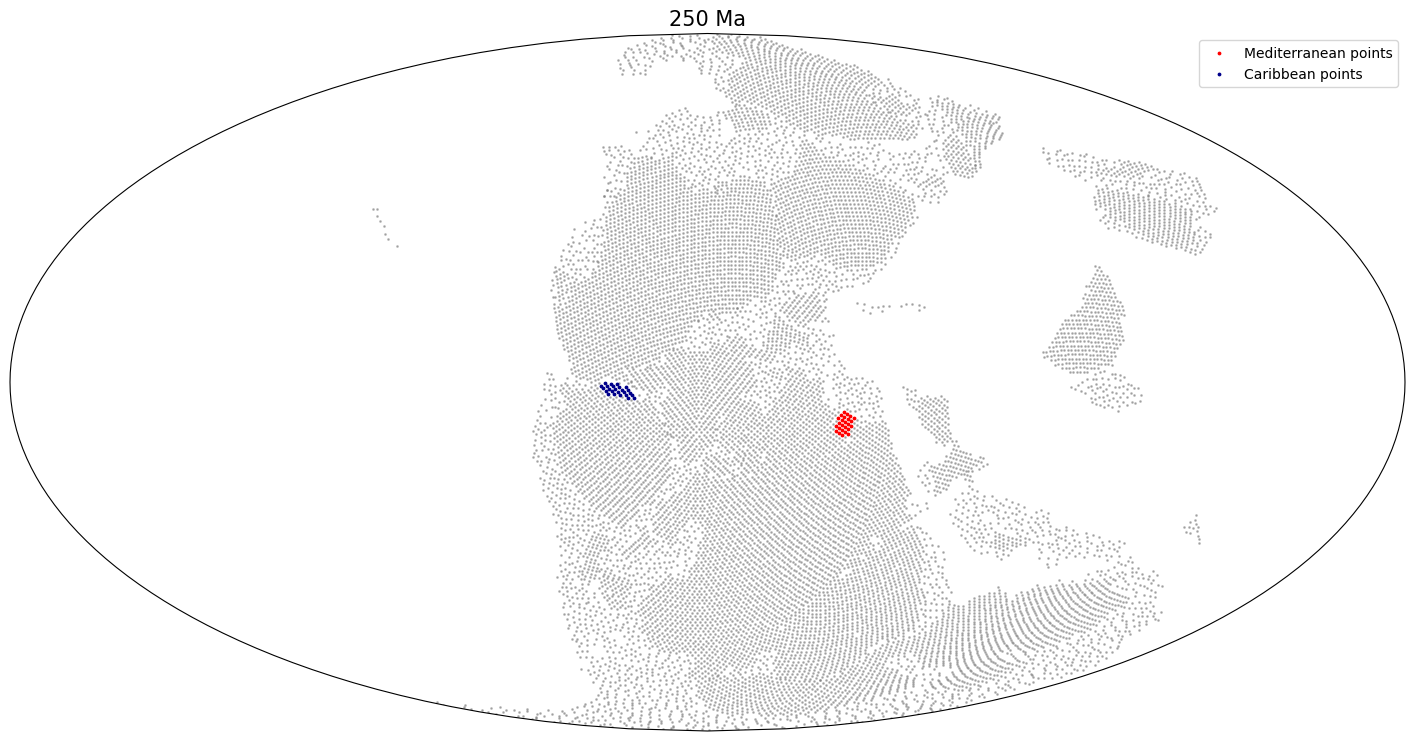

In [245]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

fig = plt.figure(figsize=(18, 16))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mollweide())  # 👈 eje con proyección

t = 43

longitudes = shelf_lonlatAge[:, t, 0]
latitudes = shelf_lonlatAge[:, t, 1]

coords_med = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_med])
coords_car = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_car])

# scatter base
ax.scatter(longitudes, latitudes, s=1, alpha=0.5, color='gray', transform=ccrs.PlateCarree())

# puntos resaltados
ax.scatter(coords_med[:,0], coords_med[:,1], s=3, alpha=1.0, color='red', label='Mediterranean points', transform=ccrs.PlateCarree())
ax.scatter(coords_car[:,0], coords_car[:,1], s=3, alpha=1.0, color='darkblue', label='Caribbean points', transform=ccrs.PlateCarree())

ax.set_global()            # 👈 ahora sí funciona
#ax.coastlines()
ax.set_title('250 Ma', fontsize=15)

plt.legend()
plt.show()



In [277]:
landShelfOceanMask

(720, 360, 82)

In [253]:
shelf_lonlatAge.shape

(49688, 82, 3)

In [317]:
landShelfOceanMask

array([[[nan, nan,  2., ...,  2.,  2., nan],
        [nan, nan,  2., ...,  2.,  2., nan],
        [nan, nan,  2., ...,  2.,  2., nan],
        ...,
        [ 0., nan,  0., ...,  0.,  0., nan],
        [ 0., nan,  0., ...,  0.,  0., nan],
        [ 0., nan,  0., ...,  0.,  0., nan]],

       [[nan, nan,  2., ...,  2.,  2., nan],
        [nan, nan,  2., ...,  2.,  2., nan],
        [nan, nan,  2., ...,  2.,  2., nan],
        ...,
        [ 0., nan,  0., ...,  0.,  0., nan],
        [ 0., nan,  0., ...,  0.,  0., nan],
        [ 0., nan,  0., ...,  0.,  0., nan]],

       [[nan, nan,  2., ...,  2.,  2., nan],
        [nan, nan,  2., ...,  2.,  2., nan],
        [nan, nan,  2., ...,  2.,  2., nan],
        ...,
        [ 0., nan,  0., ...,  0.,  0., nan],
        [ 0., nan,  0., ...,  0.,  0., nan],
        [ 0., nan,  0., ...,  0.,  0., nan]],

       ...,

       [[nan, nan,  2., ...,  2.,  2., nan],
        [nan, nan,  2., ...,  2.,  2., nan],
        [nan, nan,  2., ...,  2.,  2., nan

For the diversity time series

In [ ]:
# Fila 3: 3 figuras
ax4 = fig.add_subplot(gs[3, 1:5])

A = np.zeros((len(indices_car)))
mean_values = np.zeros(shelf_lonlatAge.shape[1])
year = np.full(shelf_lonlatAge.shape[1], np.nan)

for a in range(1,D_car.shape[0]):
    for t in range(shelf_lonlatAge.shape[1]):
        for i in range(len(indices_car)):
            A[i] = D_car[a,i,t,0]

        mean_values[t] = np.nanmean(A)

        if not np.isnan(mean_values[t]):
            year[t] = Point_timeslices[0][t]

    # ⚠️ Solo después de llenar 'year', creamos el mask
    mask = ~np.isnan(year)

    ax4.plot(-year[mask], mean_values[mask], color='darkblue', alpha=0.8, linewidth=0.5, label='Media')

ax4.set_xlabel('Time (Ma)', fontsize=12)
ax4.set_ylabel('Diversity', fontsize=12)

ax4.set_ylim(0,35)

ax4.set_title('Caribbean', fontsize=15)

ax5 = fig.add_subplot(gs[3, 7:11])
A = np.zeros((len(indices_med)))
mean_values = np.zeros(shelf_lonlatAge.shape[1])
year = np.full(shelf_lonlatAge.shape[1], np.nan)

for a in range(1,D_med.shape[0]):
    for t in range(shelf_lonlatAge.shape[1]):
        for i in range(len(indices_med)):
            A[i] = D_med[a,i,t,0]

        mean_values[t] = np.nanmean(A)

        if not np.isnan(mean_values[t]):
            year[t] = Point_timeslices[0][t]

    # ⚠️ Solo después de llenar 'year', creamos el mask
    mask = ~np.isnan(year)

    ax5.plot(-year[mask], mean_values[mask], color='r', alpha=0.8, linewidth=0.5, label='Media')

ax5.set_xlabel('Time (Ma)', fontsize=12)
ax5.set_ylabel('Diversity', fontsize=12)

ax5.set_title('Mediterranean', fontsize=15)

#ax6 = fig.add_subplot(gs[3, 8:12])
#A = np.zeros((len(indices_pac)))
#mean_values = np.zeros(shelf_lonlatAge.shape[1])
#year = np.full(shelf_lonlatAge.shape[1], np.nan)

#for a in range(1,D_pac.shape[0]):
#    for t in range(shelf_lonlatAge.shape[1]):
#        for i in range(len(indices_pac)):
#            A[i] = D_pac[a,i,t,0]
#
#        mean_values[t] = np.nanmean(A)
#
#    # ⚠️ Solo después de llenar 'year', creamos el mask
#    mask = ~np.isnan(year)
#
#    ax6.plot(-year[mask], mean_values[mask], color='green', alpha=0.8, linewidth=0.5, label='Media')
#
#ax6.set_xlim(-np.nanmax(year), -np.nanmin(year))
#
#ax6.set_xlabel('Time (Ma)')
#ax6.set_ylabel('Diversity')
#
#ax6.set_title('Pacific', fontsize=15)


# Fila 4: 4 figuras
ax7 = fig.add_subplot(gs[2, 0:3], projection=ccrs.Mollweide(central_longitude=0))

t=0

longitudes = shelf_lonlatAge[:, t, 0]
latitudes = shelf_lonlatAge[:, t, 1]

coords_med = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_med])
#coords_pac = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_pac])
coords_car = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_car])


scatter = ax7.scatter(longitudes, latitudes, s=1, alpha=0.05, color='gray', transform=ccrs.PlateCarree())

highlight_1 = ax7.scatter(coords_med[:,0], coords_med[:,1], s=0.5, alpha=1.0, color='red',  label='Mediterranean points', transform = ccrs.PlateCarree())
#highlight_2 = ax7.scatter(coords_pac[:,0], coords_pac[:,1], s=3, alpha=1.0, color='green',  label='Pacific points', transform = ccrs.PlateCarree())
highlight_3 = ax7.scatter(coords_car[:,0], coords_car[:,1], s=0.5, alpha=1.0, color='darkblue',  label='Caribbean points', transform = ccrs.PlateCarree())

ax7.set_global()

gl7=ax7.gridlines(draw_labels=False, linestyle='--', color='lightgray', alpha=0.5)


ax7.set_title('541 Ma', fontsize=15)


ax8 = fig.add_subplot(gs[2, 3:6] , projection=ccrs.Mollweide(central_longitude=0))

t=25

longitudes = shelf_lonlatAge[:, t, 0]
latitudes = shelf_lonlatAge[:, t, 1]

coords_med = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_med])
#coords_pac = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_pac])
coords_car = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_car])


scatter = ax8.scatter(longitudes, latitudes, s=1, alpha=0.03, color='gray', transform=ccrs.PlateCarree())

highlight_1 = ax8.scatter(coords_med[:,0], coords_med[:,1], s=0.5, alpha=1.0, color='red', label='Mediterranean points', transform=ccrs.PlateCarree())
#highlight_2 = ax8.scatter(coords_pac[:,0], coords_pac[:,1], s=3, alpha=1.0, color='green',  label='Pacific points', transform=ccrs.PlateCarree())
highlight_3 = ax8.scatter(coords_car[:,0], coords_car[:,1], s=0.5, alpha=1.0, color='darkblue',  label='Caribbean points', transform=ccrs.PlateCarree())


ax8.set_global()

gl8=ax8.gridlines(draw_labels=False, linestyle='--', color='lightgray', alpha=0.5)


ax8.legend(loc='lower right', bbox_to_anchor=(1.4, -0.5), markerscale=5)

ax8.set_title('390 Ma', fontsize=15)


ax9 = fig.add_subplot(gs[2, 6:9], projection=ccrs.Mollweide(central_longitude=0))

t=43

longitudes = shelf_lonlatAge[:, t, 0]
latitudes = shelf_lonlatAge[:, t, 1]

coords_med = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_med])
#coords_pac = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_pac])
coords_car = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_car])


scatter = ax9.scatter(longitudes, latitudes, s=1, alpha=0.03, color='gray', transform=ccrs.PlateCarree())

highlight_1 = ax9.scatter(coords_med[:,0], coords_med[:,1], s=0.5, alpha=1.0, color='red',  label='Mediterranean points', transform=ccrs.PlateCarree())
#highlight_2 = ax9.scatter(coords_pac[:,0], coords_pac[:,1], s=3, alpha=1.0, color='green', label='Pacific points', transform=ccrs.PlateCarree())
highlight_3 = ax9.scatter(coords_car[:,0], coords_car[:,1], s=0.5, alpha=1.0, color='darkblue',  label='Caribbean points', transform=ccrs.PlateCarree())

ax9.set_global()

gl9=ax9.gridlines(draw_labels=False, linestyle='--', color='lightgray', alpha=0.5)


ax9.set_title('250 Ma', fontsize=15)

ax10 = fig.add_subplot(gs[2, 9:12], projection=ccrs.Mollweide(central_longitude=0))
t=57

longitudes = shelf_lonlatAge[:, t, 0]
latitudes = shelf_lonlatAge[:, t, 1]

coords_med = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_med])
#coords_pac = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_pac])
coords_car = np.array([[shelf_lonlatAge[i, t, 0], shelf_lonlatAge[i, t, 1]] for i in indices_car])


scatter = ax10.scatter(longitudes, latitudes, s=1, alpha=0.05, color='gray', transform=ccrs.PlateCarree())

highlight_1 = ax10.scatter(coords_med[:,0], coords_med[:,1], s=0.5, alpha=1.0, color='red', label='Mediterranean points', transform=ccrs.PlateCarree())
#highlight_2 = ax10.scatter(coords_pac[:,0], coords_pac[:,1], s=3, alpha=1.0, color='green',  label='Pacific points', transform=ccrs.PlateCarree())
highlight_3 = ax10.scatter(coords_car[:,0], coords_car[:,1], s=0.5, alpha=1.0, color='darkblue', label='Caribbean points', transform=ccrs.PlateCarree())

ax10.set_title('150 Ma', fontsize=15)

gl10=ax10.gridlines(draw_labels=False, linestyle='--', color='lightgray', alpha=0.5)

ax10.set_global()


array([[nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       ...,
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.]])

In [328]:
np.unique(LSOmask)

array([0., 1., 2.])

In [4]:
landShelfOceanMask.shape

(720, 360, 82)

In [5]:
plt.scatter(landShelfOceanMask[:,:,74])

TypeError: scatter() missing 1 required positional argument: 'y'